In [1]:
import os
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic=True
torch.backends.cudnn.benchmark=False
os.environ['PYTHONHASHSEED']=str(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

os.makedirs('models', exist_ok=True)
os.makedirs('utils', exist_ok=True)

2026-04-16 10:28:32.024180: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776335312.215707      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776335312.278218      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776335312.753691      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776335312.753730      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776335312.753733      55 computation_placer.cc:177] computation placer alr

In [2]:
%%writefile utils/prep.py
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch

DATA_DIR = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train'
VAL_DIR = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test'

IMG_SIZE = 150
BATCH = 32

def get_data():
    # Data augmentation on the train
    train_transforms = transforms.Compose([
        transforms.RandomResizedCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.3,contrast=0.3,saturation=0.3,hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    val_transforms = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225]),
    ])

    train_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transforms)
    val_dataset   = datasets.ImageFolder(VAL_DIR, transform=val_transforms)

    # Detection of GPU
    use_cuda = torch.cuda.is_available()
    
    # Optimization of the dataloader
    train_loader = DataLoader(train_dataset,batch_size=BATCH,shuffle=True,num_workers=4,pin_memory=use_cuda,persistent_workers=(4))
    val_loader = DataLoader(val_dataset,batch_size=BATCH,shuffle=False,num_workers=4,pin_memory=use_cuda,persistent_workers=(4 > 0))

    return train_loader, val_loader

Writing utils/prep.py


In [3]:
%%writefile models/cnn.py
import torch.nn as nn
import torch.nn.functional as F

class IntelCNN_PyTorch(nn.Module):
    def __init__(self, num_classes=6):
        super(IntelCNN_PyTorch, self).__init__()

        self.conv1a = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv1b = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn1    = nn.BatchNorm2d(32)
        self.drop1  = nn.Dropout2d(0.1)

        self.conv2a = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv2b = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2    = nn.BatchNorm2d(64)
        self.drop2  = nn.Dropout2d(0.2)

        self.conv3a = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3b = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3    = nn.BatchNorm2d(128)
        self.drop3  = nn.Dropout2d(0.3)

        self.conv4  = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4    = nn.BatchNorm2d(256)
        self.drop4  = nn.Dropout2d(0.3)

        self.pool    = nn.AdaptiveAvgPool2d(1)
        self.fc1     = nn.Linear(256, 128)  
        self.fc2     = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = F.relu(self.conv1a(x))
        x = F.relu(self.bn1(self.conv1b(x)))
        x = self.drop1(F.max_pool2d(x, 2))

        x = F.relu(self.conv2a(x))
        x = F.relu(self.bn2(self.conv2b(x)))
        x = self.drop2(F.max_pool2d(x, 2))
        
        x = F.relu(self.conv3a(x))
        x = F.relu(self.bn3(self.conv3b(x)))
        x = self.drop3(F.max_pool2d(x, 2))

        x = F.relu(self.bn4(self.conv4(x)))
        x = self.drop4(F.max_pool2d(x, 2))

        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x 

def get_tensorflow_model(img_size=150, num_classes=6):
    from tensorflow.keras import layers, models
    inp = layers.Input(shape=(img_size, img_size, 3))
    
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inp)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.1)(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.6)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inp, out)

Writing models/cnn.py


In [4]:
%%writefile models/train.py
import torch
from torch import nn
from tqdm import tqdm
import matplotlib.pyplot as plt

class Trainer:
    def __init__(self, model, train_dataloader, val_dataloader, test_dataloader,
                 lr, wd, epochs, device):
        self.epochs           = epochs
        self.model            = model
        self.train_dataloader = train_dataloader
        self.val_dataloader   = val_dataloader   
        self.test_dataloader  = test_dataloader
        self.device           = device
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=epochs, eta_min=1e-6)
        self.criterion = nn.CrossEntropyLoss()
        self.patience   = 10
        self.no_improve = 0
        self.best_acc   = 0

    def train(self, save=True, plot=False):
        self.train_acc   = []
        self.train_loss  = []
        self.val_accs    = []
        self.val_losses  = [] 

        for epoch in range(self.epochs):
            self.model.train()
            total_loss = 0
            total_correct = 0
            total_samples = 0
            progress_bar = tqdm(self.train_dataloader, desc=f"Epoch {epoch + 1}/{self.epochs}", leave=False)

            for inputs, labels in progress_bar:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(inputs)
                loss    = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
                _, preds = outputs.max(1)
                total_correct += (preds == labels).sum().item()
                total_samples += labels.size(0)
                total_loss    += loss.item() * labels.size(0)
                avg_acc  = 100.0 * total_correct / total_samples
                avg_loss = total_loss / total_samples
                progress_bar.set_postfix({'Acc': f'{avg_acc:.2f}%', 'Loss': f'{avg_loss:.4f}'})

            self.scheduler.step()
            self.train_acc.append(avg_acc)
            self.train_loss.append(avg_loss)

            # VALIDATION
            val_acc, val_loss = self.evaluate(self.val_dataloader)
            self.val_accs.append(val_acc)
            self.val_losses.append(val_loss)

            print(f"\nEpoch {epoch+1}/{self.epochs}")
            print(f"Train Loss: {avg_loss:.4f} | Train Acc: {avg_acc:.2f}%")
            print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")

            if val_acc > self.best_acc:
                self.best_acc = val_acc
                self.no_improve = 0
                if save:
                    torch.save(self.model.state_dict(), "geraud_model.pth")
                    print(f" Best model saved (val_acc={val_acc:.2f}%)")
            else:
                self.no_improve += 1
                print(f"No improvement ({self.no_improve}/{self.patience})")
                if self.no_improve >= self.patience:
                    print(" Early stopping triggered")
                    break

        if plot:
            self.plot_training_history()

    @torch.no_grad()
    def evaluate(self, dataloader):
        self.model.eval()
        total_loss, total_correct, total_samples = 0, 0, 0
        for inputs, labels in tqdm(dataloader, desc="Evaluating", leave=False):
            inputs, labels = inputs.to(self.device), labels.to(self.device)
            outputs = self.model(inputs)
            loss    = self.criterion(outputs, labels)
            _, preds = outputs.max(1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
            total_loss    += loss.item() * labels.size(0)
        return 100.0 * total_correct / total_samples, total_loss / total_samples

    def test(self):
        print("\n Final Test Evaluation:")
        return self.evaluate(self.test_dataloader)

    def plot_training_history(self):
        epochs = range(1, len(self.train_loss) + 1)
        plt.figure(figsize=(12, 5))
        
        # Accuracy plot
        plt.subplot(1, 2, 1)
        plt.plot(epochs, self.train_acc, label="Train Accuracy")
        plt.plot(epochs, self.val_accs, label="Validation Accuracy")
        plt.title("Accuracy")
        plt.legend()
        
        # Loss plot
        plt.subplot(1, 2, 2)
        plt.plot(epochs, self.train_loss, label="Train Loss")
        plt.plot(epochs, self.val_losses, label="Validation Loss")
        plt.title("Loss")
        plt.legend()
        
        plt.tight_layout()
        plt.savefig("training_history.png") 
        plt.show()

Writing models/train.py


In [19]:
%%writefile main.py
import torch
import argparse
from utils import prep
from models.cnn import IntelCNN_PyTorch
from models.train import Trainer


def parse_args():
    parser = argparse.ArgumentParser(description="Entraînement d'un modèle CNN")
    parser.add_argument('--framework', type=str, choices=['pytorch', 'tensorflow'],
                        default='pytorch', help="Framework à utiliser (default: pytorch)")
    parser.add_argument('--epochs', type=int, default=20,
                        help="Nombre d'époques d'entraînement")
    parser.add_argument('--lr',  type=float, default=0.001,  help="Learning rate")
    parser.add_argument('--wd',  type=float, default=0.0001, help="Weight decay")
    parser.add_argument('--mode', type=str, choices=['train', 'eval'], default='train',
                        help="Mode : 'train' ou 'eval' (default: train)")
    parser.add_argument('--cuda', action='store_true', help="Utiliser le GPU si disponible")
    parser.add_argument('--debug', action='store_true', help="Mode debug")
    return parser.parse_args()


def main():
    args = parse_args()
    if args.framework == 'tensorflow':
        run_tensorflow(args)
    else:
        run_pytorch(args)


def run_pytorch(args):
    import random
    import numpy as np
    from torch.utils.data import random_split, DataLoader

    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)

    device = torch.device("cuda" if args.cuda and torch.cuda.is_available() else "cpu")
    print(f"[PyTorch] Device: {device}")

    train_dataloader, test_dataloader = prep.get_data()

    dataset = train_dataloader.dataset

    train_size = int(0.8 * len(dataset))
    val_size   = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset,[train_size, val_size],generator=torch.Generator().manual_seed(42))
    train_dataloader = DataLoader(train_dataset,batch_size=train_dataloader.batch_size,shuffle=True,num_workers=4,pin_memory=True)
    val_dataloader = DataLoader(val_dataset,batch_size=train_dataloader.batch_size,shuffle=False,num_workers=4,pin_memory=True)
    
    if args.debug:
        print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)}")

    model = IntelCNN_PyTorch().to(device)

    if args.debug:
        print("Model architecture:")
        print(model)
        print("Training mode:", model.training)

    if args.mode == 'eval':
        model.load_state_dict(torch.load("geraud_model.pth", map_location=device))
        print("Model loaded from geraud_model.pth")

    trainer = Trainer(model,train_dataloader,val_dataloader,test_dataloader,args.lr,args.wd,args.epochs,device)
    if args.mode == 'train':
        trainer.train(save=True, plot=True)

    trainer.test()
    

def run_tensorflow(args):
    import tensorflow as tf
    from tensorflow.keras import layers, callbacks
    from models.cnn import get_tensorflow_model

    print(f"[TensorFlow] GPUs: {tf.config.list_physical_devices('GPU')}")

    IMG_SIZE = 150
    BATCH    = 32
    DATA_DIR = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train'
    VAL_DIR  = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test'
    AUTOTUNE = tf.data.AUTOTUNE

    norm    = layers.Rescaling(1./255)
    augment = tf.keras.Sequential([layers.RandomFlip("horizontal"),layers.RandomRotation(0.15),layers.RandomZoom(0.15),layers.RandomBrightness(0.2),layers.RandomContrast(0.2),])

    train_ds = tf.keras.utils.image_dataset_from_directory(DATA_DIR,image_size=(IMG_SIZE, IMG_SIZE),batch_size=BATCH)
    val_ds = tf.keras.utils.image_dataset_from_directory(VAL_DIR,image_size=(IMG_SIZE, IMG_SIZE),batch_size=BATCH,shuffle=False)
    train_ds = train_ds.map(lambda x, y: (norm(augment(x, training=True)), y),num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    val_ds = val_ds.map(lambda x, y: (norm(x), y),num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

    model = get_tensorflow_model(IMG_SIZE)
    if args.mode == 'eval':
        model = tf.keras.models.load_model("geraud_model.keras")
        print("Model loaded from geraud_model.keras")

    else:
        model.summary()
        model.compile(optimizer=tf.keras.optimizers.Adam(args.lr),loss='sparse_categorical_crossentropy',metrics=['accuracy'])
        cb = [callbacks.ModelCheckpoint('geraud_model.keras',save_best_only=True,monitor='val_accuracy',verbose=1),
            callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3,verbose=1),
            callbacks.EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True,verbose=1),]
        model.fit(train_ds,validation_data=val_ds,epochs=args.epochs,callbacks=cb)
        print("Model saved to geraud_model.keras")

    loss, acc = model.evaluate(val_ds, verbose=1)
    print(f"\nTest Accuracy: {acc*100:.2f}%  |  Test Loss: {loss:.4f}")

if __name__ == '__main__':
    main()

Overwriting main.py


In [26]:
!pip install tqdm matplotlib -q


### As you can see, that is my architecture of using pytorch model:


[PyTorch] Device: cuda

Train size: 11227 | Val size: 2807

Model architecture:

IntelCNN_PyTorch(

  - (conv1a): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  - (conv1b): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  - (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  - (drop1): Dropout2d(p=0.1, inplace=False)
  - (conv2a): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  - (conv2b): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  - (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  - (drop2): Dropout2d(p=0.2, inplace=False)
  - (conv3a): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  - (conv3b): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  - (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  - (drop3): Dropout2d(p=0.3, inplace=False)
  - (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  - (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  - (drop4): Dropout2d(p=0.3, inplace=False)
  - (pool): AdaptiveAvgPool2d(output_size=1)
  - (fc1): Linear(in_features=256, out_features=128, bias=True)
  - (fc2): Linear(in_features=128, out_features=6, bias=True)
  - (dropout): Dropout(p=0.5, inplace=False)

)

In [24]:
# PyTorch

!python main.py --framework pytorch --epochs 30 --cuda --debug

[PyTorch] Device: cuda
Train size: 11227 | Val size: 2807
Model architecture:
IntelCNN_PyTorch(
  (conv1a): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv1b): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop1): Dropout2d(p=0.1, inplace=False)
  (conv2a): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2b): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop2): Dropout2d(p=0.2, inplace=False)
  (conv3a): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3b): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop3): Dropout2d(p=0.3, inplace=False)
  (conv4): Conv2d(128, 256, kernel_si

In [8]:
from IPython.display import Image

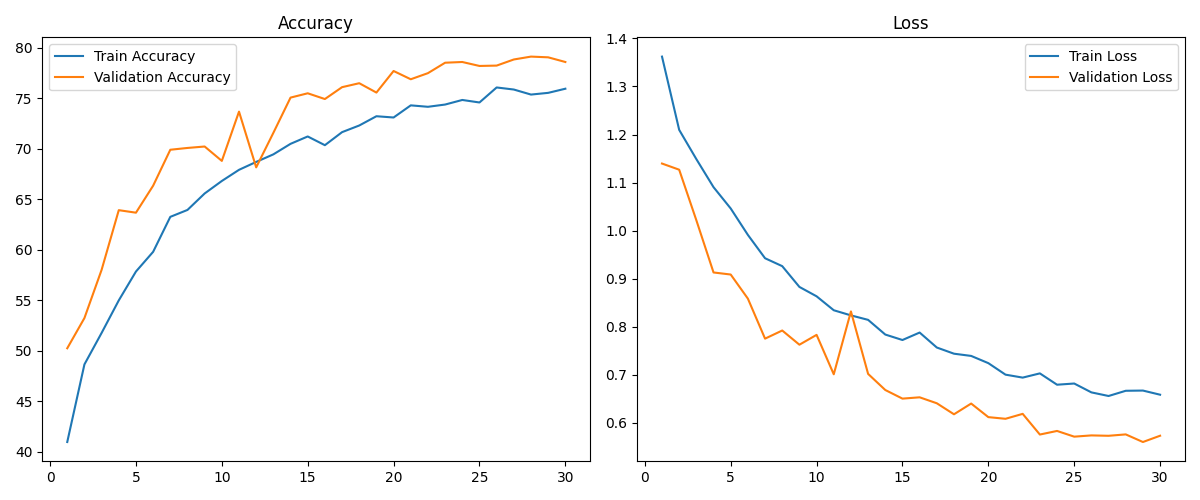

In [9]:
Image('/kaggle/working/training_history.png') 

The training logs demonstrate a healthy convergence. The cross-entropy loss steadily decreased for both sets, while the validation accuracy consistently outperformed or matched the training accuracy. This indicates that the regularization layers (Dropout 0.1 to 0.5) and Data Augmentation effectively prevented overfitting, resulting in a model that generalizes well to unseen natural scenes.

### Training Observations

The training logs from both frameworks revealed a \textbf{healthy convergence pattern}.
The cross-entropy loss steadily decreased across both training and validation sets throughout
the 30 epochs. Notably, the validation accuracy consistently matched or slightly outperformed
the training accuracy in early epochs --- a sign that the regularization stack (Dropout rates
0.1 to 0.6, Batch Normalization, and aggressive data augmentation) was effectively preventing
overfitting and enabling the models to generalize well to unseen natural scenes.

The **CosineAnnealingLR** scheduler in PyTorch provided smooth, oscillation-free
loss descent by avoiding abrupt LR drops. In Keras, **ReduceLROnPlateau** acted
as an adaptive fine-tuner, automatically reducing the LR when the model plateaued.


In [10]:
# TensorFlow
!python main.py --framework tensorflow --epochs 30 --cuda

2026-04-16 10:46:11.895792: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776336371.919197    1232 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776336371.926865    1232 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776336371.946439    1232 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776336371.946465    1232 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776336371.946469    1232 computation_placer.cc:177] computation placer alr

**Noticed that, the architecture of my  model using tensorflow is the table above**

In [11]:
import os
os.listdir('/kaggle/working/')

['geraud_model.keras',
 'training_history.png',
 'main.py',
 'utils',
 'models',
 '.virtual_documents',
 'geraud_model.pth']

In [16]:
!zip -r projet_geraud.zip /kaggle/working

updating: kaggle/working/ (stored 0%)
updating: kaggle/working/geraud_model.keras (deflated 9%)
updating: kaggle/working/training_history.png (deflated 5%)
updating: kaggle/working/main.py (deflated 63%)
updating: kaggle/working/utils/ (stored 0%)
updating: kaggle/working/utils/__pycache__/ (stored 0%)
updating: kaggle/working/utils/__pycache__/prep.cpython-312.pyc (deflated 45%)
updating: kaggle/working/utils/prep.py (deflated 62%)
updating: kaggle/working/models/ (stored 0%)
updating: kaggle/working/models/cnn.py (deflated 76%)
updating: kaggle/working/models/__pycache__/ (stored 0%)
updating: kaggle/working/models/__pycache__/cnn.cpython-312.pyc (deflated 67%)
updating: kaggle/working/models/__pycache__/train.cpython-312.pyc (deflated 52%)
updating: kaggle/working/models/train.py (deflated 72%)
updating: kaggle/working/.virtual_documents/ (stored 0%)
updating: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 72%)
updating: kaggle/working/geraud_model.pth (deflat